# Chapter 16: Quantum Phase Estimation

Quantum Phase Estimation (QPE) algorithm.

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [18]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library import  HamiltonianGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Statevector, Operator
from qiskit.quantum_info import SparsePauliOp
from Chapter16_QPE_functions import myQPESingleBit, myQPEMultiBit, QiskitQPEWrapper

print('Setup complete!')

Setup complete!


## Hamiltonian

[[-0.25+0.4330127j  0.75+0.4330127j]
 [ 0.75+0.4330127j -0.25+0.4330127j]]


<IPython.core.display.Latex object>

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


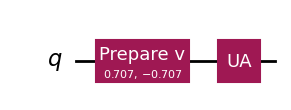

In [2]:
A = np.array([[2,-1],[-1,2]])
f = 0.5
lambdaUpper = 3
t = -2*np.pi*f/lambdaUpper #Note negative
U_A = HamiltonianGate(A, time=t,label = 'UA')
print(np.array(U_A.to_matrix()))
v = np.array([1/np.sqrt(2),-1/np.sqrt(2)])
circuit = QuantumCircuit(1)
circuit.prepare_state(Statevector(v) ,0,'Prepare v')
circuit.append(U_A, qargs=[0])
psi = Statevector(circuit)
display(psi.draw('latex'))
circuit.draw('mpl') 

## Control gate

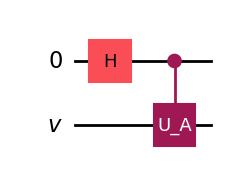

In [3]:
zeroQubit = QuantumRegister(1, '0')
vQubit = QuantumRegister(1, 'v')
circuit = QuantumCircuit(zeroQubit,vQubit) 
circuit.h(0)
UMatrix = 1/np.sqrt(2)*np.array([[1,1],[1j,-1j]]) 
U = UnitaryGate(UMatrix,'U_A')
UControl = U.control(1)
circuit.append(UControl,[0,1])
circuit.draw('mpl') 

## Probability Model

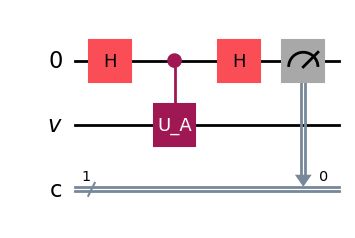

In [4]:
zeroQubit = QuantumRegister(1, '0')
vQubit = QuantumRegister(1, 'v')
cBit = ClassicalRegister(1, 'c')
circuit = QuantumCircuit(zeroQubit,vQubit,cBit) 
circuit.h(0)
UMatrix = 1/np.sqrt(2)*np.array([[1,1],[1j,-1j]]) 
U = UnitaryGate(UMatrix,'U_A')
UControl = U.control(1)
circuit.append(UControl,[0,1])
circuit.h(0)
circuit.measure([0], [0]) 
circuit.draw('mpl') 


### Example 1

In [5]:
A = np.array([[1,0],[0,0.75]])
v = np.array([1,0])
lambdaUpper = 2

[thetaEstimates,probabilities] = myQPESingleBit(A,v,lambdaUpper,nShots=1000)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)

Counts: {'1': 1000}
Theta estimates: [0.5]
Probabilities: [1.]


### Example 2

In [6]:
A = np.array([[1,0],[0,0.75]])
v = np.array([0,1])
lambdaUpper = 2

[thetaEstimates,probabilities] = myQPESingleBit(A,v,lambdaUpper,nShots=1000)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)

Counts: {'1': 848, '0': 152}
Theta estimates: [0.5 0. ]
Probabilities: [0.848 0.152]


## Multiple digit QPE 

### Multibit Example 1

In [7]:
A = np.array([[1,0],[0,0.75]])
v = np.array([0,1])
lambdaUpper = 2
nThetaBits = 2

[thetaEstimates,probabilities] = myQPEMultiBit(A,v,lambdaUpper,m = nThetaBits, nShots=1000)
thetaTilde = np.sum(thetaEstimates*probabilities)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)
print("thetaTilde: ", thetaTilde)

{'01': 428, '10': 428, '00': 60, '11': 84}
Theta estimates: [0.25 0.5  0.75 0.  ]
Probabilities: [0.428 0.428 0.084 0.06 ]
thetaTilde:  0.384


### Multibit Example 2

In [8]:
nThetaBits = 3

[thetaEstimates,probabilities] = myQPEMultiBit(A,v,lambdaUpper,m = nThetaBits, nShots=1000)
thetaTilde = np.sum(thetaEstimates*probabilities)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)
print("thetaTilde: ", thetaTilde)

{'011': 1000}
Theta estimates: [0.375]
Probabilities: [1.]
thetaTilde:  0.375


### Multibit Example 3

In [9]:
nThetaBits = 5

[thetaEstimates,probabilities] = myQPEMultiBit(A,v,lambdaUpper,m = nThetaBits, nShots=1000)
thetaTilde = np.sum(thetaEstimates*probabilities)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)
print("thetaTilde: ", thetaTilde)

{'01100': 1000}
Theta estimates: [0.375]
Probabilities: [1.]
thetaTilde:  0.375


## Qiskit QPE Wrapper

## QPE Example 1

In [10]:
A = np.array([[1,0],[0,0.75]])
v0 = np.array([0,1])
v1 = np.array([1,0])
Lambda = [0.75,1]
a = [1/np.sqrt(2),1/np.sqrt(2)]
a= [0,1]
v = a[0]*v0 + a[1]*v1
lambdaUpper = 2
m = 1




## QPE Example 2

In [11]:
A = np.array([[2,-1],[-1,2]])
v0 = np.array([1/np.sqrt(2),1/np.sqrt(2)])
v1 = np.array([1/np.sqrt(2),-1/np.sqrt(2)])
Lambda = [1,3]
a = [1,0]
v = a[0]*v0 + a[1]*v1
lambdaUpper = 6
m = 4



## QPE Example 3

In [12]:
A = np.array([[1,0,0,-0.5],[0,1,0,0],[0,0,1,0],[-0.5,0,0,1]])
v0 = np.array([1/np.sqrt(2),0,0,1/np.sqrt(2)])
v1 = np.array([0,1,0,0])
v2 = np.array([0,0,1,0])
v3 = np.array([1/np.sqrt(2),0,0,-1/np.sqrt(2)])
Lambda = [0.5,1,1,1.5]
#a = [1/np.sqrt(4),1/np.sqrt(4),1/np.sqrt(4),1/np.sqrt(4)]
a = [0,0,1,0]
v = a[0]*v0 + a[1]*v1 + a[2]*v2 + a[3]*v3
lambdaUpper = 3
m = 2
[thetaEstimates,P] = myQPESingleBit(A,v,lambdaUpper)	
print("thetaEstimates:",thetaEstimates)
print("probabilities:", P)
thetaTilde = np.sum(thetaEstimates*P)
print("thetaTilde:", thetaTilde)
print("EigenvalueTilde:",thetaTilde*lambdaUpper)

Counts: {'1': 751, '0': 249}
thetaEstimates: [0.5 0. ]
probabilities: [0.751 0.249]
thetaTilde: 0.3755
EigenvalueTilde: 1.1265


In [13]:
m = 3
A = np.array([[2,-1,0,0],[-1,2,-1,0],[0,-1,2,-1],[0,0,-1,2]])
v = np.random.rand(4)
v = v/np.linalg.norm(v)
f = 0.5
lambdaUpper = 4



## Trotterization error

In [17]:
# Pauli matrices
Z = np.array([[1, 0], [0, -1]])
X = np.array([[0, 1], [1, 0]])
 
# A = 2Z - 0.5X
A = 2*Z - 0.5*X
A1 = 2*Z
A2 = -0.5*X
 
lambdaUpper = 5
t = 2*np.pi/lambdaUpper
 
# Exact Hamiltonian
U_exact = expm(1j*A*t)
 
# Trotter convergence (first-order only)
for r in [1, 2, 5, 10, 50, 100]:
    dt = t / r
    step1 = expm(1j * A1 * dt) @ expm(1j * A2 * dt)
    U_trotter1 = np.linalg.matrix_power(step1, r)
    err1 = np.linalg.norm(U_exact - U_trotter1)
    print(f"r={r:3d}: 1st-order err={err1:.6f}")

# Trotter convergence (second-order only)
for r in [1, 2, 5, 10, 50, 100]:
    dt = t / r
    step2 = expm(1j * A1 * dt / 2) @ expm(1j * A2 * dt) @ expm(1j * A1 * dt / 2)
    U_trotter2 = np.linalg.matrix_power(step2, r)
    err2 = np.linalg.norm(U_exact - U_trotter2)
    print(f"r={r:3d}: 2nd-order err={err2:.6f}")

r=  1: 1st-order err=1.022180
r=  2: 1st-order err=0.268470
r=  5: 1st-order err=0.092678
r= 10: 1st-order err=0.045427
r= 50: 1st-order err=0.009028
r=100: 1st-order err=0.004513
r=  1: 2nd-order err=0.710502
r=  2: 2nd-order err=0.091288
r=  5: 2nd-order err=0.012592
r= 10: 2nd-order err=0.003087
r= 50: 2nd-order err=0.000123
r=100: 2nd-order err=0.000031


### Qiskit Trotterization

In [19]:
# A = 2Z - 0.5X
A = np.array([[2, -0.5], [-0.5, -2]])
lambdaUpper = 5
t = 2*np.pi/lambdaUpper

# Exact Hamiltonian
U_exact = expm(1j*A*t)

# Pauli decomposition
H_pauli = SparsePauliOp.from_list([('Z', 2.0), ('X', -0.5)])

# First-order Trotter
for r in [1, 2, 5, 10, 50]:
    synth = LieTrotter(reps=r)
    evo = PauliEvolutionGate(H_pauli, time=-t, synthesis=synth)
    qc = QuantumCircuit(1)
    qc.append(evo, [0])
    U_trot = np.array(Operator(qc.decompose()))
    print(f"r={r:2d}: 1st-order err = "
          f"{np.linalg.norm(U_exact - U_trot):.6f}")

# Second-order Trotter
for r in [1, 2, 5, 10, 50]:
    synth = SuzukiTrotter(order=2, reps=r)
    evo = PauliEvolutionGate(H_pauli, time=-t, synthesis=synth)
    qc = QuantumCircuit(1)
    qc.append(evo, [0])
    U_trot = np.array(Operator(qc.decompose()))
    print(f"r={r:2d}: 2nd-order err = "
          f"{np.linalg.norm(U_exact - U_trot):.6f}")

r= 1: 1st-order err = 1.022180
r= 2: 1st-order err = 0.268470
r= 5: 1st-order err = 0.092678
r=10: 1st-order err = 0.045427
r=50: 1st-order err = 0.009028
r= 1: 2nd-order err = 0.710502
r= 2: 2nd-order err = 0.091288
r= 5: 2nd-order err = 0.012592
r=10: 2nd-order err = 0.003087
r=50: 2nd-order err = 0.000123
